# Thesis Tier-1 data-exploration figures

Generates the five load-bearing figures for the thesis Methodology chapter:

1. Cohort class-balance contrast (LPCD vs BigLunge).
2. Domain-shift panel (HU, in-plane spacing, slice thickness, slice count).
3. Pipeline input panel (2D crop / MIL whole-slice / 3D mid-axial).
4. BigLunge mask multifocality (connected components per tumour mask).
5. Mask quality contrast (LPCD expert mask vs BigLunge algorithmic mask).

All figures use a thesis-grade style: serif font, no titles (captions live in LaTeX), tight layout, 300 dpi PNG.

Outputs land under `data_pipeline/notebooks/output/thesis_tier1/`. Copy approved figures into `68f744c9dee90549fab66800/Images/Methodology/` from there.

Set `TESTING = True` for a smoke run on a small subset; `TESTING = False` produces the canonical full-cohort figures (slower because of HU sampling and connected-component scans).

## 0) Setup, imports, thesis style

In [11]:
import json
import os
import random
import sys
import warnings
from collections import Counter
from pathlib import Path
from typing import Any, Dict, List, Tuple

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
from scipy import ndimage as ndi

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

REPO = Path("/home/hansstem/SCLC-Classification")
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from sclc.data.loaders import (
    BIGLUNGE_CLASS_MAP,
    CLASS_MAP,
    CLASS_NAMES,
    get_biglunge_data_list,
    get_lung_pet_ct_dx_data_list,
    load_patient_labels,
)
from sclc.data.exclusions import EMPTY_TUMOR_MASK, TRUNCATED_LUNG_MASK

SEED = 42
random.seed(SEED); np.random.seed(SEED)

TESTING = False  # set True for a quick smoke run
HU_SAMPLE_VOLUMES_PER_COHORT = 30 if not TESTING else 4  # for Figure 2 HU histogram
MULTIFOCAL_LIMIT = None if not TESTING else 30           # for Figure 4

# Active data paths (match sclc/main.py)
LPCD_DATA = "/home/data/Lung-PET-CT-Dx-Clean"
BL_DATA = "/home/data/TrainingData"
BL_CSV = "/home/data/TrainingData/patients_parameters.csv"

OUT_DIR = REPO / "data_pipeline" / "notebooks" / "output" / "thesis_tier1"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUT_DIR / "_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Thesis style — serif, no titles, single-column 3.4" / two-column 6.7".
TEXTWIDTH_IN = 6.7   # full \textwidth in inches at 12pt body
COLWIDTH_IN = 3.3    # half-width
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "axes.titlesize": 0,           # captions live in LaTeX
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 1.0,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "figure.dpi": 110,
})

# Color-blind safe palette (Wong 2011). Class colors stay consistent across figures.
CLASS_COLORS = {
    0: "#0072B2",  # ADC — blue
    1: "#D55E00",  # SCLC — vermillion
    2: "#009E73",  # SCC — green
}
COHORT_COLORS = {
    "LPCD": "#56B4E9",      # sky blue
    "BigLunge": "#CC79A7",  # reddish purple
}
CLASS_SHORT = ["ADC", "SCLC", "SCC"]

print(f"Output dir: {OUT_DIR}")
print(f"TESTING = {TESTING}")

Output dir: /home/hansstem/SCLC-Classification/data_pipeline/notebooks/output/thesis_tier1
TESTING = False


## 1) Build canonical cohort lists

Reuses `get_lung_pet_ct_dx_data_list` and `get_biglunge_data_list` with the same seed (42) and split fractions the training pipeline uses, so the patient identity in every figure matches what the model trains on.

In [ ]:
# EDA is split-agnostic: the thesis pipeline uses 5-fold stratified CV
# (configs/experiments/*.yaml), but these figures describe cohort-level
# properties. Passing val_frac=test_frac=0.0 keeps every patient in a single
# bucket and avoids exercising the deprecated single 70/15/15 split path.
lpcd_splits = get_lung_pet_ct_dx_data_list(
    data_path=LPCD_DATA, val_frac=0.0, test_frac=0.0, seed=SEED, testing=TESTING,
)
bl_splits = get_biglunge_data_list(
    data_path=BL_DATA, csv_path=BL_CSV, val_frac=0.0, test_frac=0.0, seed=SEED, testing=TESTING,
)

def _patient_table(splits: Dict[str, List[Dict[str, Any]]], cohort: str) -> pd.DataFrame:
    rows = []
    seen = set()
    for _, entries in splits.items():
        for e in entries:
            pid = str(e['patient_id'])
            key = (cohort, pid)
            if key in seen:
                # one row per (cohort, patient) — first scan wins
                continue
            seen.add(key)
            rows.append({
                'cohort': cohort,
                'patient_id': pid,
                'label': int(e['scan_label']),
                'image': e['image'],
                'mask': e.get('mask'),
                'lung_mask': e.get('lung_mask'),
            })
    return pd.DataFrame(rows)

df_lpcd_pat = _patient_table(lpcd_splits, 'LPCD')
df_bl_pat = _patient_table(bl_splits, 'BigLunge')
df_pat = pd.concat([df_lpcd_pat, df_bl_pat], ignore_index=True)
df_pat['class_name'] = df_pat['label'].map(lambda i: CLASS_SHORT[i])

print('\nPatient counts (one row per patient, first scan kept):')
print(df_pat.groupby(['cohort', 'class_name']).size().unstack(fill_value=0))
lpcd_n = int((df_pat['cohort'] == 'LPCD').sum())
bl_n = int((df_pat['cohort'] == 'BigLunge').sum())
print(f'  LPCD total = {lpcd_n}, BigLunge total = {bl_n}')
df_pat.to_csv(CACHE_DIR / 'patient_table.csv', index=False)


## Figure 1 — Cohort class-balance contrast

Two-panel side-by-side bar chart. Same color per class across both panels so the asymmetry between LPCD's adenocarcinoma-heavy distribution (\~71/11/18) and BigLunge's near-uniform distribution (\~35/31/34) reads in one glance.

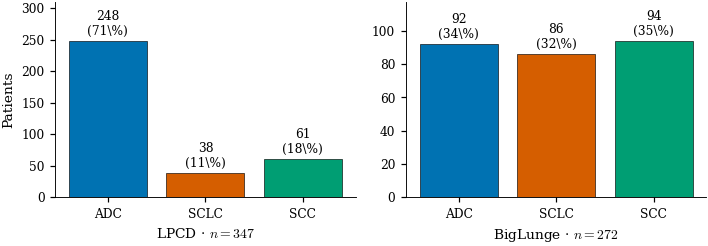

Saved: /home/hansstem/SCLC-Classification/data_pipeline/notebooks/output/thesis_tier1/fig1_class_balance.png


In [12]:
def fig_class_balance(df: pd.DataFrame, savepath: Path) -> Path:
    counts = (
        df.groupby(["cohort", "label"]).size().unstack(fill_value=0)
        .reindex(columns=[0, 1, 2], fill_value=0)
        .reindex(index=["LPCD", "BigLunge"], fill_value=0)
    )
    fig, axes = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 2.5), sharey=False)
    for ax, cohort in zip(axes, ["LPCD", "BigLunge"]):
        c = counts.loc[cohort]
        total = int(c.sum())
        x = np.arange(3)
        bars = ax.bar(
            x, c.values,
            color=[CLASS_COLORS[i] for i in [0, 1, 2]],
            edgecolor="black", linewidth=0.4,
        )
        for xi, v in zip(x, c.values):
            pct = 100.0 * v / max(1, total)
            ax.text(xi, v + max(c.values) * 0.02, f"{int(v)}\n({pct:.0f}\\%)",
                    ha="center", va="bottom", fontsize=8)
        ax.set_xticks(x)
        ax.set_xticklabels(CLASS_SHORT)
        ax.set_ylabel("Patients" if cohort == "LPCD" else "")
        ax.set_xlabel(f"{cohort} \u00b7 $n={total}$")
        ax.set_ylim(0, max(c.values) * 1.25)
    fig.tight_layout()
    fig.savefig(savepath)
    plt.show()
    return savepath

fig1_path = fig_class_balance(df_pat, OUT_DIR / "fig1_class_balance.png")
print(f"Saved: {fig1_path}")

## 2) Cache volume metadata for Figure 2 (domain shift)

Reads NIfTI headers (cheap) for every patient. Writes `volume_metadata.csv` so re-runs are instant. HU statistics need actual voxel data, so we read a stratified sample of `HU_SAMPLE_VOLUMES_PER_COHORT` volumes per cohort and pool the voxels.

In [13]:
def header_metadata(path: str) -> Dict[str, Any]:
    img = nib.load(path)
    h = img.header
    zooms = h.get_zooms()
    shape = img.shape
    return {
        "dim_x": int(shape[0]) if len(shape) > 0 else 0,
        "dim_y": int(shape[1]) if len(shape) > 1 else 0,
        "dim_z": int(shape[2]) if len(shape) > 2 else 0,
        "spacing_x": float(zooms[0]) if len(zooms) > 0 else float("nan"),
        "spacing_y": float(zooms[1]) if len(zooms) > 1 else float("nan"),
        "spacing_z": float(zooms[2]) if len(zooms) > 2 else float("nan"),
    }

META_CSV = CACHE_DIR / "volume_metadata.csv"
if META_CSV.exists() and not TESTING:
    df_meta = pd.read_csv(META_CSV)
    print(f"Loaded cached metadata: {len(df_meta)} rows from {META_CSV}")
else:
    rows = []
    for _, r in df_pat.iterrows():
        try:
            md = header_metadata(r["image"])
        except Exception as e:
            print(f"  skip {r['patient_id']}: {e}")
            continue
        rows.append({
            "cohort": r["cohort"],
            "patient_id": r["patient_id"],
            "label": r["label"],
            "image": r["image"],
            **md,
        })
    df_meta = pd.DataFrame(rows)
    df_meta.to_csv(META_CSV, index=False)
    print(f"Wrote {len(df_meta)} rows to {META_CSV}")

summary = df_meta.groupby("cohort")[["dim_z", "spacing_x", "spacing_z"]].describe(percentiles=[0.5])
print(summary[[c for c in summary.columns if c[1] in ("min", "50%", "max", "mean")]])

Loaded cached metadata: 619 rows from /home/hansstem/SCLC-Classification/data_pipeline/notebooks/output/thesis_tier1/_cache/volume_metadata.csv
               dim_z                      spacing_x                      \
                mean   min    50%     max      mean       min       50%   
cohort                                                                    
BigLunge  587.488971  31.0  601.0  1557.0  0.738942  0.546875  0.742188   
LPCD      191.374640   5.0   64.0   600.0  0.742784  0.544922  0.765625   

                   spacing_z                            
               max      mean       min       50%   max  
cohort                                                  
BigLunge  0.947266  0.750552  0.300049  0.549992  10.0  
LPCD      0.976562  3.159884  0.625000  5.000000  10.0  


In [14]:
HU_NPZ = CACHE_DIR / f"hu_sample_n{HU_SAMPLE_VOLUMES_PER_COHORT}.npz"

def sample_hu(df_meta: pd.DataFrame, cohort: str, n: int, voxels_per_volume: int = 200_000) -> np.ndarray:
    sub = df_meta[df_meta["cohort"] == cohort]
    rng = np.random.default_rng(SEED)
    # Stratified sample across classes to keep the histogram representative.
    parts = []
    for cls in (0, 1, 2):
        pool = sub[sub["label"] == cls]
        if len(pool) == 0:
            continue
        take = min(len(pool), max(1, n // 3))
        parts.append(pool.sample(n=take, random_state=SEED))
    chosen = pd.concat(parts) if parts else sub.head(0)
    voxels = []
    for path in chosen["image"].tolist():
        try:
            arr = nib.load(path).get_fdata(dtype=np.float32).ravel()
            if arr.size > voxels_per_volume:
                idx = rng.choice(arr.size, size=voxels_per_volume, replace=False)
                arr = arr[idx]
            voxels.append(arr)
        except Exception as e:
            print(f"  HU read failed for {path}: {e}")
    if not voxels:
        return np.array([], dtype=np.float32)
    return np.concatenate(voxels).astype(np.float32)

if HU_NPZ.exists() and not TESTING:
    d = np.load(HU_NPZ)
    hu_lpcd = d["lpcd"]; hu_bl = d["biglunge"]
    print(f"Loaded cached HU samples: LPCD={hu_lpcd.size:,}, BL={hu_bl.size:,}")
else:
    print(f"Sampling HU from {HU_SAMPLE_VOLUMES_PER_COHORT} volumes per cohort ...")
    hu_lpcd = sample_hu(df_meta, "LPCD", HU_SAMPLE_VOLUMES_PER_COHORT)
    hu_bl = sample_hu(df_meta, "BigLunge", HU_SAMPLE_VOLUMES_PER_COHORT)
    np.savez_compressed(HU_NPZ, lpcd=hu_lpcd, biglunge=hu_bl)
    print(f"Saved {HU_NPZ}: LPCD={hu_lpcd.size:,}, BL={hu_bl.size:,}")

Loaded cached HU samples: LPCD=6,000,000, BL=6,000,000


## Figure 2 — Domain-shift panel

2 × 2 grid:

1. HU intensity distribution (kernel density on log y-scale, full window $[-1024, 3071]$ marked).
2. In-plane voxel spacing.
3. Slice thickness (z-spacing).
4. Slice count per volume.

Two cohorts overlaid on the same axes for direct contrast.

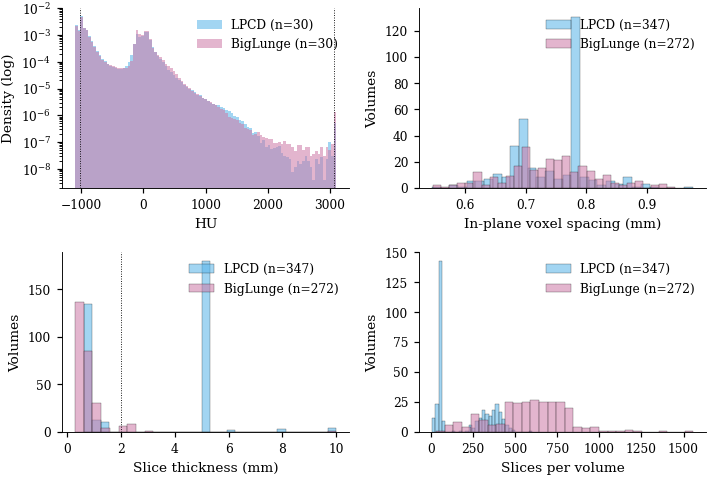

Saved: /home/hansstem/SCLC-Classification/data_pipeline/notebooks/output/thesis_tier1/fig2_domain_shift.png


In [15]:
def fig_domain_shift(df_meta: pd.DataFrame, hu_lpcd: np.ndarray, hu_bl: np.ndarray, savepath: Path) -> Path:
    fig, axes = plt.subplots(2, 2, figsize=(TEXTWIDTH_IN, 4.6))

    # 1. HU histogram (clip to a sensible window for visibility).
    ax = axes[0, 0]
    bins = np.linspace(-1100, 3100, 100)
    if hu_lpcd.size:
        ax.hist(np.clip(hu_lpcd, -1100, 3100), bins=bins, color=COHORT_COLORS["LPCD"],
                alpha=0.55, density=True, label=f"LPCD (n={HU_SAMPLE_VOLUMES_PER_COHORT})")
    if hu_bl.size:
        ax.hist(np.clip(hu_bl, -1100, 3100), bins=bins, color=COHORT_COLORS["BigLunge"],
                alpha=0.55, density=True, label=f"BigLunge (n={HU_SAMPLE_VOLUMES_PER_COHORT})")
    ax.axvline(-1024, color="black", linestyle=":", linewidth=0.6)
    ax.axvline(3071, color="black", linestyle=":", linewidth=0.6)
    ax.set_yscale("log")
    ax.set_xlabel("HU")
    ax.set_ylabel("Density (log)")
    ax.legend(frameon=False, loc="upper right")

    # 2. In-plane spacing (use spacing_x; spacing_y is ~equal in CT).
    ax = axes[0, 1]
    for cohort in ["LPCD", "BigLunge"]:
        v = df_meta.loc[df_meta["cohort"] == cohort, "spacing_x"].dropna().values
        if v.size:
            ax.hist(v, bins=30, color=COHORT_COLORS[cohort], alpha=0.55,
                    edgecolor="black", linewidth=0.3, label=f"{cohort} (n={v.size})")
    ax.set_xlabel("In-plane voxel spacing (mm)")
    ax.set_ylabel("Volumes")
    ax.legend(frameon=False)

    # 3. Slice thickness.
    ax = axes[1, 0]
    for cohort in ["LPCD", "BigLunge"]:
        v = df_meta.loc[df_meta["cohort"] == cohort, "spacing_z"].dropna().values
        if v.size:
            ax.hist(v, bins=30, color=COHORT_COLORS[cohort], alpha=0.55,
                    edgecolor="black", linewidth=0.3, label=f"{cohort} (n={v.size})")
    ax.axvline(2.0, color="black", linestyle=":", linewidth=0.6)
    ax.set_xlabel("Slice thickness (mm)")
    ax.set_ylabel("Volumes")
    ax.legend(frameon=False)

    # 4. Slice count per volume.
    ax = axes[1, 1]
    for cohort in ["LPCD", "BigLunge"]:
        v = df_meta.loc[df_meta["cohort"] == cohort, "dim_z"].dropna().values
        if v.size:
            ax.hist(v, bins=30, color=COHORT_COLORS[cohort], alpha=0.55,
                    edgecolor="black", linewidth=0.3, label=f"{cohort} (n={v.size})")
    ax.set_xlabel("Slices per volume")
    ax.set_ylabel("Volumes")
    ax.legend(frameon=False)

    fig.tight_layout()
    fig.savefig(savepath)
    plt.show()
    return savepath

fig2_path = fig_domain_shift(df_meta, hu_lpcd, hu_bl, OUT_DIR / "fig2_domain_shift.png")
print(f"Saved: {fig2_path}")

## Figure 3 — Pipeline input panel

Three columns showing what each pipeline actually feeds the model after its deterministic transform prefix. Same patient and class across all three columns where possible (LPCD, since it carries the expert tumour mask).

* **2D** — 96-px tumour-centred crop on the resampled grid.
* **MIL** — 224×224 whole-slice instance.
* **3D** — mid-axial slice of the (224, 224, 128) crop.

Implemented by composing the same MONAI transforms the training pipelines use, with augmentations off.

Example patient: Lung_Dx-A0056 (class ADC)
  using post-spacing slice_idx=49 for Lung_Dx-A0056


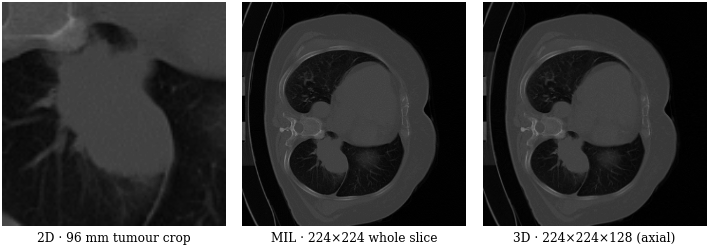

Saved: /home/hansstem/SCLC-Classification/data_pipeline/notebooks/output/thesis_tier1/fig3_pipeline_input.png


In [16]:
from monai.transforms import (
    Compose,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    ScaleIntensityRanged,
    Resized,
    SqueezeDimd,
)
from sclc.data.transforms import (
    LoadNiftiWithRGBSupportd,
    SliceSelectd,
    CropAroundTumord,
    ExtractSubVolumed,
)
from sclc.data.dataset_2d import _scan_tumor_slice_indices

# Pick one LPCD patient with a mask, one per class if possible.
candidates = df_lpcd_pat[df_lpcd_pat["mask"].notna()]
examples = []
for cls in (0, 1, 2):
    sub = candidates[candidates["label"] == cls]
    if len(sub):
        examples.append(sub.iloc[0])
if not examples:
    raise RuntimeError("No LPCD patients with masks found.")
ex = examples[0]  # use the first one (ADC) for the main panel
print(f"Example patient: {ex['patient_id']} (class {CLASS_SHORT[ex['label']]})")


# Pick a tumour-bearing slice index *in the post-Spacing(1,1,2) grid*, matching
# what _build_2d_pipeline's SliceSelectd will index against. Scanning the raw
# NIfTI on disk would give an index in the native grid and SliceSelectd would
# then land on a wrong anatomical depth (the mask appears empty). Same
# correctness constraint biglunge_audit.ipynb calls out.
def median_tumor_slice_post_spacing(mask_path: str, pixdim=(1.0, 1.0, 2.0), min_pixels: int = 1) -> int:
    slices = _scan_tumor_slice_indices(mask_path, min_pixels=min_pixels, pixdim=pixdim)
    if not slices:
        raise RuntimeError(f"No tumour slices >= {min_pixels} px in resampled mask: {mask_path}")
    return int(slices[len(slices) // 2])


# 2D pipeline: replicate _build_2d_pipeline (deterministic prefix only, no augs/normalize so HU display matches the other panels).
def render_2d(image_path: str, mask_path: str, slice_idx: int) -> np.ndarray:
    pipe = Compose([
        LoadNiftiWithRGBSupportd(keys=["image", "tumor_mask"]),
        EnsureChannelFirstd(keys=["image", "tumor_mask"], channel_dim="no_channel"),
        Orientationd(keys=["image", "tumor_mask"], axcodes="RAS"),
        Spacingd(keys=["image", "tumor_mask"], pixdim=(1.0, 1.0, 2.0), mode=["bilinear", "nearest"]),
        SliceSelectd(keys=["image", "tumor_mask"], slice_key="slice_idx"),
        CropAroundTumord(keys=["image"], source_key="tumor_mask", patch_size=(96, 96, 1)),
        ScaleIntensityRanged(keys=["image"], a_min=-1024, a_max=3071, b_min=0.0, b_max=1.0, clip=True),
        Resized(keys=["image"], spatial_size=(224, 224, 1), mode="trilinear"),
        SqueezeDimd(keys=["image"], dim=-1),
    ])
    out = pipe({"image": image_path, "tumor_mask": mask_path, "slice_idx": slice_idx})
    img = out["image"]
    arr = img.detach().cpu().numpy() if hasattr(img, "detach") else np.asarray(img)
    return arr.squeeze()


# MIL DAPT instance: same prefix as 2D, no tumour crop (whole slice).
def render_mil_slice(image_path: str, slice_idx: int) -> np.ndarray:
    pipe = Compose([
        LoadNiftiWithRGBSupportd(keys=["image"]),
        EnsureChannelFirstd(keys=["image"], channel_dim="no_channel"),
        Orientationd(keys=["image"], axcodes="RAS"),
        Spacingd(keys=["image"], pixdim=(1.0, 1.0, 2.0), mode="bilinear"),
        SliceSelectd(keys=["image"], slice_key="slice_idx"),
        ScaleIntensityRanged(keys=["image"], a_min=-1024, a_max=3071, b_min=0.0, b_max=1.0, clip=True),
        Resized(keys=["image"], spatial_size=(224, 224, 1), mode="trilinear"),
        SqueezeDimd(keys=["image"], dim=-1),
    ])
    out = pipe({"image": image_path, "slice_idx": slice_idx})
    img = out["image"]
    arr = img.detach().cpu().numpy() if hasattr(img, "detach") else np.asarray(img)
    return arr.squeeze()


# 3D pipeline: matches get_val_transforms_3d on Lung-PET-CT-Dx (mask key is "mask").
def render_3d(image_path: str, mask_path: str) -> Tuple[np.ndarray, int]:
    pipe = Compose([
        LoadNiftiWithRGBSupportd(keys=["image", "mask"]),
        EnsureChannelFirstd(keys=["image", "mask"], channel_dim="no_channel"),
        Orientationd(keys=["image", "mask"], axcodes="RAS"),
        Spacingd(keys=["image", "mask"], pixdim=(1.5, 1.5, 2.0), mode=["bilinear", "nearest"]),
        ScaleIntensityRanged(keys=["image"], a_min=-1024, a_max=3071, b_min=0.0, b_max=1.0, clip=True),
        ExtractSubVolumed(keys=["image", "mask"], num_slices=128, allow_missing_keys=True),
        Resized(keys=["image", "mask"], spatial_size=(224, 224, 128), mode=["trilinear", "nearest"]),
    ])
    out = pipe({"image": image_path, "mask": mask_path})
    img = out["image"]
    arr = img.detach().cpu().numpy() if hasattr(img, "detach") else np.asarray(img)
    arr = arr.squeeze()  # (224, 224, 128)
    msk = out["mask"]
    msk = msk.detach().cpu().numpy() if hasattr(msk, "detach") else np.asarray(msk)
    msk = msk.squeeze()
    z_sums = (msk > 0).sum(axis=(0, 1))
    if z_sums.sum() > 0:
        z_show = int(np.argmax(z_sums))
    else:
        z_show = arr.shape[-1] // 2
    return arr, z_show


def fig_pipeline_input(ex_row: pd.Series, savepath: Path) -> Path:
    sl = median_tumor_slice_post_spacing(ex_row["mask"])
    print(f"  using post-spacing slice_idx={sl} for {ex_row['patient_id']}")
    img2d = render_2d(ex_row["image"], ex_row["mask"], sl)
    img_mil = render_mil_slice(ex_row["image"], sl)
    vol3d, z3 = render_3d(ex_row["image"], ex_row["mask"])
    img3d = vol3d[..., z3]

    fig, axes = plt.subplots(1, 3, figsize=(TEXTWIDTH_IN, 2.6))
    titles = [
        "2D · 96 mm tumour crop",
        "MIL · 224×224 whole slice",
        "3D · 224×224×128 (axial)",
    ]
    for ax, im, t in zip(axes, [img2d, img_mil, img3d], titles):
        ax.imshow(im, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlabel(t, fontsize=8)
        for s in ax.spines.values():
            s.set_visible(False)
    fig.tight_layout()
    fig.savefig(savepath)
    plt.show()
    return savepath


fig3_path = fig_pipeline_input(ex, OUT_DIR / "fig3_pipeline_input.png")
print(f"Saved: {fig3_path}")

## Figure 4 — BigLunge mask multifocality

For every BigLunge patient with a `_label_tc.nii.gz`, count 3D-connected components in the binary tumour mask. Histogram with median and 95th-percentile lines marked.

This is the figure the thesis cites in §4.4.3 (\"68 to 77\\% multifocal, median 2, $P_{95}=8$\") with no figure backing it today.

In [17]:
MULTIFOCAL_CSV = CACHE_DIR / "biglunge_multifocality.csv"

def count_components(mask_path: str, min_voxels: int = 50) -> Dict[str, int]:
    arr = nib.load(mask_path).get_fdata()
    if arr.ndim == 4:
        arr = arr[..., 0]
    binary = arr > 0
    labelled, n_raw = ndi.label(binary)
    if n_raw == 0:
        return {"n_components_raw": 0, "n_components_thresh": 0, "largest_voxels": 0, "total_voxels": 0}
    sizes = np.bincount(labelled.ravel())[1:]  # drop background
    n_thresh = int((sizes >= min_voxels).sum())
    return {
        "n_components_raw": int(n_raw),
        "n_components_thresh": n_thresh,
        "largest_voxels": int(sizes.max()),
        "total_voxels": int(sizes.sum()),
    }

if MULTIFOCAL_CSV.exists() and not TESTING:
    df_mf = pd.read_csv(MULTIFOCAL_CSV)
    print(f"Loaded cached multifocality table: {len(df_mf)} rows from {MULTIFOCAL_CSV}")
else:
    bl_with_mask = df_bl_pat[df_bl_pat["mask"].notna()].copy()
    if MULTIFOCAL_LIMIT is not None:
        bl_with_mask = bl_with_mask.head(MULTIFOCAL_LIMIT)
    rows = []
    for i, r in enumerate(bl_with_mask.itertuples(index=False)):
        if i % 25 == 0:
            print(f"  ... {i}/{len(bl_with_mask)}")
        try:
            stats = count_components(r.mask)
        except Exception as e:
            print(f"  fail {r.patient_id}: {e}")
            continue
        rows.append({"patient_id": r.patient_id, "label": r.label, **stats})
    df_mf = pd.DataFrame(rows)
    df_mf.to_csv(MULTIFOCAL_CSV, index=False)
    print(f"Saved {MULTIFOCAL_CSV}: {len(df_mf)} rows")

n_total = len(df_mf)
n_multifocal_raw = int((df_mf["n_components_raw"] >= 2).sum())
n_multifocal_thresh = int((df_mf["n_components_thresh"] >= 2).sum())
print(f"Multifocal (raw \u22652 components): {n_multifocal_raw}/{n_total} = {100*n_multifocal_raw/max(1,n_total):.1f}%")
print(f"Multifocal (thresh \u226550 vox each): {n_multifocal_thresh}/{n_total} = {100*n_multifocal_thresh/max(1,n_total):.1f}%")

  ... 0/272
  ... 25/272
  ... 50/272
  ... 75/272
  ... 100/272
  ... 125/272
  ... 150/272
  ... 175/272
  ... 200/272
  ... 225/272
  ... 250/272
Saved /home/hansstem/SCLC-Classification/data_pipeline/notebooks/output/thesis_tier1/_cache/biglunge_multifocality.csv: 272 rows
Multifocal (raw ≥2 components): 221/272 = 81.2%
Multifocal (thresh ≥50 vox each): 194/272 = 71.3%


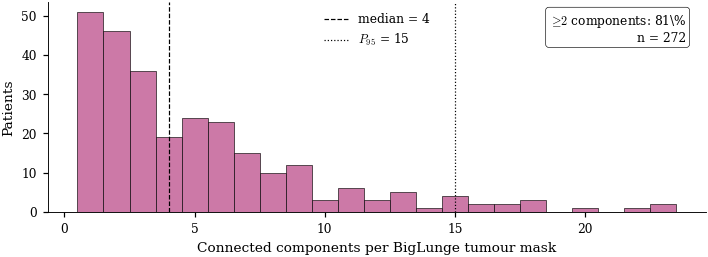

Saved: /home/hansstem/SCLC-Classification/data_pipeline/notebooks/output/thesis_tier1/fig4_multifocality.png


In [18]:
def fig_multifocality(df_mf: pd.DataFrame, savepath: Path) -> Path:
    fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 2.6))
    v = df_mf["n_components_raw"].values
    if v.size == 0:
        raise RuntimeError("Empty multifocality table.")
    cap = int(np.percentile(v, 99))
    bins = np.arange(0.5, max(cap, 10) + 1.5, 1.0)
    ax.hist(v, bins=bins, color=COHORT_COLORS["BigLunge"], edgecolor="black", linewidth=0.4)
    median = int(np.median(v)); p95 = int(np.percentile(v, 95))
    ax.axvline(median, color="black", linestyle="--", linewidth=0.8, label=f"median = {median}")
    ax.axvline(p95, color="black", linestyle=":", linewidth=0.8, label=f"$P_{{95}}$ = {p95}")
    ax.set_xlabel("Connected components per BigLunge tumour mask")
    ax.set_ylabel("Patients")
    pct = 100 * (v >= 2).mean()
    ax.text(0.97, 0.95, f"$\\geq\\!2$ components: {pct:.0f}\\%\nn = {v.size}",
            transform=ax.transAxes, va="top", ha="right", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="black", linewidth=0.4))
    ax.legend(frameon=False, loc="upper center")
    fig.tight_layout()
    fig.savefig(savepath)
    plt.show()
    return savepath

fig4_path = fig_multifocality(df_mf, OUT_DIR / "fig4_multifocality.png")
print(f"Saved: {fig4_path}")

## Figure 5 — Mask quality contrast (LPCD expert vs BigLunge algorithmic)

Three rows (one per class) × two columns (LPCD expert / BigLunge algorithmic). Every panel shows the resampled axial slice that the model sees, with the corresponding tumour-mask contour overlaid.

**Honesty note (CLAUDE.md):** if the BigLunge auto-segmentations look reasonable here, that *weakens* the seg-quality-as-failure-mode argument the thesis is trying to make. Pick examples that include the failure modes the audit notebook flags (small/missed tumours, multifocal masks, off-target hits) rather than the cleanest examples. Manual tweak below the helper if needed.

In [ ]:
PIXDIM_2D = (1.0, 1.0, 2.0)


def load_resampled_slice(image_path: str, mask_path: str, pixdim=PIXDIM_2D) -> Tuple[np.ndarray, np.ndarray]:
    """Return (image_slice, mask_slice) on the 2D pipeline grid (RAS, 1×1×2 mm), HU-scaled to [0, 1]."""
    pipe = Compose([
        LoadNiftiWithRGBSupportd(keys=["image", "mask"]),
        EnsureChannelFirstd(keys=["image", "mask"], channel_dim="no_channel"),
        Orientationd(keys=["image", "mask"], axcodes="RAS"),
        Spacingd(keys=["image", "mask"], pixdim=pixdim, mode=["bilinear", "nearest"]),
        ScaleIntensityRanged(keys=["image"], a_min=-1024, a_max=3071, b_min=0.0, b_max=1.0, clip=True),
    ])
    out = pipe({"image": image_path, "mask": mask_path})
    img = out["image"].detach().cpu().numpy() if hasattr(out["image"], "detach") else np.asarray(out["image"])
    msk = out["mask"].detach().cpu().numpy() if hasattr(out["mask"], "detach") else np.asarray(out["mask"])
    img = img.squeeze(); msk = msk.squeeze()
    z_sums = (msk > 0).sum(axis=(0, 1))
    if z_sums.sum() == 0:
        z_show = img.shape[-1] // 2
    else:
        z_show = int(np.argmax(z_sums))
    return img[..., z_show], (msk[..., z_show] > 0.5).astype(np.uint8)


def pick_example_per_class(df_pat: pd.DataFrame, cohort: str, seed: int = SEED) -> Dict[int, pd.Series]:
    sub = df_pat[(df_pat["cohort"] == cohort) & df_pat["mask"].notna()].copy()
    out = {}
    for cls in (0, 1, 2):
        rows = sub[sub["label"] == cls]
        if len(rows):
            out[cls] = rows.sample(n=1, random_state=seed + cls).iloc[0]
    return out


lpcd_examples = pick_example_per_class(df_pat, "LPCD")
bl_examples = pick_example_per_class(df_pat, "BigLunge")
print("LPCD examples:", {k: v["patient_id"] for k, v in lpcd_examples.items()})
print("BigLunge examples:", {k: v["patient_id"] for k, v in bl_examples.items()})

# To override examples manually (recommended for the final figure), set entries below.
OVERRIDE_LPCD: Dict[int, str] = {}     # e.g. {0: "Lung_Dx-A0017"}
OVERRIDE_BL: Dict[int, str] = {}       # e.g. {1: "patient_071505"}


def apply_override(picks: Dict[int, pd.Series], df_pat: pd.DataFrame, cohort: str, overrides: Dict[int, str]):
    if not overrides:
        return picks
    sub = df_pat[(df_pat["cohort"] == cohort) & df_pat["mask"].notna()]
    out = dict(picks)
    for cls, pid in overrides.items():
        rows = sub[sub["patient_id"] == pid]
        if len(rows):
            out[cls] = rows.iloc[0]
        else:
            print(f"  override miss: cohort={cohort} class={cls} pid={pid}")
    return out


lpcd_examples = apply_override(lpcd_examples, df_pat, "LPCD", OVERRIDE_LPCD)
bl_examples = apply_override(bl_examples, df_pat, "BigLunge", OVERRIDE_BL)

LPCD examples: {0: 'Lung_Dx-A0056', 1: 'Lung_Dx-B0027', 2: 'Lung_Dx-G0006'}
BigLunge examples: {0: 'patient_042556', 1: 'patient_076313', 2: 'patient_038718'}


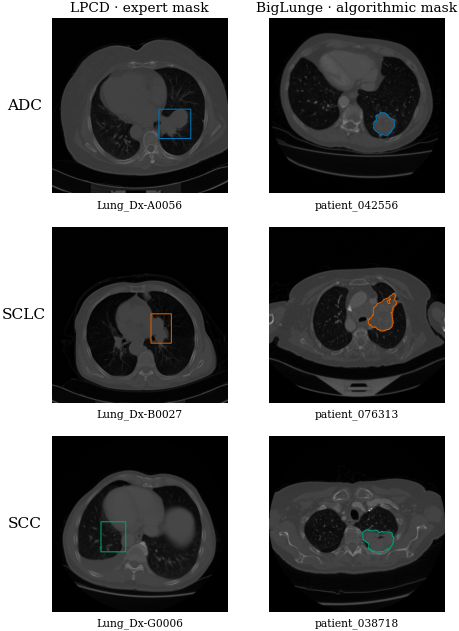

Saved: /home/hansstem/SCLC-Classification/data_pipeline/notebooks/output/thesis_tier1/fig5_mask_quality.png


In [24]:
def fig_mask_quality(
    lpcd_examples: Dict[int, pd.Series],
    bl_examples: Dict[int, pd.Series],
    savepath: Path,
) -> Path:
    n_rows = 3
    fig, axes = plt.subplots(n_rows, 2, figsize=(TEXTWIDTH_IN * 0.7, 6.0))
    col_titles = ["LPCD · expert mask", "BigLunge · algorithmic mask"]
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=9, pad=4)
    for row, cls in enumerate((0, 1, 2)):
        axes[row, 0].set_ylabel(CLASS_SHORT[cls], fontsize=10, rotation=0, labelpad=18, va="center")
        for col, picks in enumerate([lpcd_examples, bl_examples]):
            ax = axes[row, col]
            ax.set_xticks([]); ax.set_yticks([])
            for s in ax.spines.values():
                s.set_visible(False)
            r = picks.get(cls)
            if r is None:
                ax.text(0.5, 0.5, "no example", transform=ax.transAxes, ha="center", va="center", fontsize=8)
                continue
            try:
                img, msk = load_resampled_slice(r["image"], r["mask"])
            except Exception as e:
                ax.text(0.5, 0.5, f"load fail", transform=ax.transAxes, ha="center", va="center", fontsize=8)
                continue
            ax.imshow(img.T, cmap="gray", vmin=0, vmax=1, origin="lower")
            ax.contour(msk.T, levels=[0.5], colors=[CLASS_COLORS[cls]], linewidths=0.7, origin="lower")
            ax.set_xlabel(str(r["patient_id"]), fontsize=7)
    fig.tight_layout()
    fig.savefig(savepath)
    plt.show()
    return savepath

fig5_path = fig_mask_quality(lpcd_examples, bl_examples, OUT_DIR / "fig5_mask_quality.png")
print(f"Saved: {fig5_path}")

## Tier 2 — supporting figures

These five figures back specific Methodology subsections rather than carry the main argument.

* **Figure 6** — cohort-feasibility funnel (§4.3): on-disk → after split → after pipeline-specific drops.
* **Figure 7** — tumour-mask voxel-count distribution per class × cohort (§4.4): justifies `min_tumor_pixels` and shows the BigLunge tumour-burden distribution.
* **Figure 8** — LPCD slice-eligibility distribution (§4.4.1): tumour-bearing slices per volume with the `max_slices_per_volume = 8` cap marked.
* **Figure 9** — 2D augmentation grid (§4.4.1): each `strong_augs` operation in isolation.
* **Figure 10** — patient-level vs slice-level cohort sizes (§4.6.1): backs the patient-level evaluation argument numerically.

All saved to `OUT_DIR` with descriptive names (no `fig{n}_` prefix).

In [ ]:
# Figure 6 — cohort-feasibility funnel.
def fig_funnel(df_pat: pd.DataFrame, savepath: Path) -> Path:
    # LPCD funnel (counts derived directly from disk + the patient table).
    lpcd_root = Path(LPCD_DATA)
    lpcd_total = sum(1 for p in lpcd_root.iterdir() if p.is_dir())
    lpcd_valid_class = 0
    for p in lpcd_root.iterdir():
        if not p.is_dir():
            continue
        matched = [v for k, v in CLASS_MAP.items() if f"-{k}" in p.name]
        if len(matched) == 1:
            lpcd_valid_class += 1
    lpcd_split = int((df_pat["cohort"] == "LPCD").sum())
    lpcd_with_mask = int(df_pat[(df_pat["cohort"] == "LPCD") & df_pat["mask"].notna()].shape[0])

    # BigLunge funnel.
    bl_labelled = len(load_patient_labels(BL_CSV))
    bl_after_trunc = bl_labelled - len(TRUNCATED_LUNG_MASK)
    bl_after_empty = bl_after_trunc - len(EMPTY_TUMOR_MASK)
    bl_with_mask = int(df_pat[(df_pat["cohort"] == "BigLunge") & df_pat["mask"].notna()].shape[0])

    lpcd_steps = [
        ("Folders on disk", lpcd_total),
        ("Valid 3-class label", lpcd_valid_class),
        ("After patient split", lpcd_split),
        ("With tumour mask (2D)", lpcd_with_mask),
    ]
    bl_steps = [
        ("CSV labelled (3-class)", bl_labelled),
        ("After truncated-lung drop", bl_after_trunc),
        ("After empty-mask drop", bl_after_empty),
        ("With tumour mask (2D)", bl_with_mask),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 3.0))
    for ax, steps, color, cohort in zip(axes,
                                         [lpcd_steps, bl_steps],
                                         [COHORT_COLORS["LPCD"], COHORT_COLORS["BigLunge"]],
                                         ["LPCD", "BigLunge"]):
        labels, counts = zip(*steps)
        y = np.arange(len(labels))[::-1]
        ax.barh(y, counts, color=color, edgecolor="black", linewidth=0.4)
        for yi, c in zip(y, counts):
            ax.text(c + max(counts) * 0.02, yi, str(c), va="center", fontsize=8)
        ax.set_yticks(y)
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel(f"{cohort} · patients")
        ax.set_xlim(0, max(counts) * 1.18)
    fig.tight_layout()
    fig.savefig(savepath)
    plt.show()
    return savepath


fig6_path = fig_funnel(df_pat, OUT_DIR / "feasibility_funnel.png")
print(f"Saved: {fig6_path}")

In [ ]:
# Figure 7 — tumour-mask voxel-count distribution per class × cohort.
LPCD_VOX_CSV = CACHE_DIR / "lpcd_mask_voxels.csv"
if LPCD_VOX_CSV.exists() and not TESTING:
    df_lpcd_vox = pd.read_csv(LPCD_VOX_CSV)
    print(f"Loaded LPCD voxel-count cache: {len(df_lpcd_vox)} rows")
else:
    rows = []
    pool = df_lpcd_pat[df_lpcd_pat["mask"].notna()]
    for i, r in enumerate(pool.itertuples(index=False)):
        if i % 30 == 0:
            print(f"  ... {i}/{len(pool)}")
        try:
            arr = nib.load(r.mask).get_fdata()
            if arr.ndim == 4:
                arr = arr[..., 0]
            rows.append({"patient_id": r.patient_id, "label": r.label,
                         "total_voxels": int((arr > 0).sum())})
        except Exception as e:
            print(f"  fail {r.patient_id}: {e}")
    df_lpcd_vox = pd.DataFrame(rows)
    df_lpcd_vox.to_csv(LPCD_VOX_CSV, index=False)
    print(f"Wrote {LPCD_VOX_CSV}: {len(df_lpcd_vox)} rows")

# BigLunge voxel counts already computed in Figure 4's df_mf.
df_bl_vox = df_mf[["patient_id", "label", "total_voxels"]].copy()
df_lpcd_vox["cohort"] = "LPCD"; df_bl_vox["cohort"] = "BigLunge"
df_vox = pd.concat([df_lpcd_vox, df_bl_vox], ignore_index=True)
df_vox = df_vox[df_vox["total_voxels"] > 0]
df_vox["log_voxels"] = np.log10(df_vox["total_voxels"])


def fig_voxels(df_vox: pd.DataFrame, savepath: Path) -> Path:
    import matplotlib.patches as mpatches
    fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 3.4))
    width = 0.38
    base = np.arange(3)
    positions, data, colors = [], [], []
    for j, cohort in enumerate(["LPCD", "BigLunge"]):
        for cls in (0, 1, 2):
            v = df_vox[(df_vox["cohort"] == cohort) & (df_vox["label"] == cls)]["log_voxels"].values
            if len(v):
                positions.append(base[cls] + (j - 0.5) * width)
                data.append(v)
                colors.append(COHORT_COLORS[cohort])
    bp = ax.boxplot(data, positions=positions, widths=width * 0.85, patch_artist=True,
                     showfliers=True, boxprops=dict(linewidth=0.5),
                     whiskerprops=dict(linewidth=0.5), capprops=dict(linewidth=0.5),
                     medianprops=dict(color="black", linewidth=0.8),
                     flierprops=dict(marker="o", markersize=2, markerfacecolor="black",
                                     markeredgecolor="none", alpha=0.4))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color); patch.set_alpha(0.65)
    ax.set_xticks(base)
    ax.set_xticklabels(CLASS_SHORT)
    ax.set_xlabel("Class")
    ax.set_ylabel("Tumour-mask voxels (log$_{10}$, native grid)")
    handles = [mpatches.Patch(color=COHORT_COLORS[c], alpha=0.65, label=c) for c in ["LPCD", "BigLunge"]]
    ax.legend(handles=handles, frameon=False, loc="lower right")
    fig.tight_layout()
    fig.savefig(savepath)
    plt.show()
    return savepath


fig7_path = fig_voxels(df_vox, OUT_DIR / "tumour_voxel_counts.png")
print(f"Saved: {fig7_path}")

In [ ]:
# Figure 8 — LPCD slice-eligibility distribution.
LPCD_SLICES_CSV = CACHE_DIR / "lpcd_eligible_slices.csv"
if LPCD_SLICES_CSV.exists() and not TESTING:
    df_lpcd_slices = pd.read_csv(LPCD_SLICES_CSV)
    print(f"Loaded LPCD slice-count cache: {len(df_lpcd_slices)} rows")
else:
    rows = []
    pool = df_lpcd_pat[df_lpcd_pat["mask"].notna()]
    for i, r in enumerate(pool.itertuples(index=False)):
        if i % 30 == 0:
            print(f"  ... {i}/{len(pool)}")
        try:
            slices = _scan_tumor_slice_indices(r.mask, min_pixels=1)
        except Exception as e:
            print(f"  fail {r.patient_id}: {e}")
            continue
        rows.append({"patient_id": r.patient_id, "label": r.label, "n_eligible": len(slices)})
    df_lpcd_slices = pd.DataFrame(rows)
    df_lpcd_slices.to_csv(LPCD_SLICES_CSV, index=False)
    print(f"Wrote {LPCD_SLICES_CSV}: {len(df_lpcd_slices)} rows")


def fig_slice_eligibility(df_lpcd_slices: pd.DataFrame, savepath: Path) -> Path:
    fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 3.0))
    v = df_lpcd_slices["n_eligible"].values
    if v.size == 0:
        raise RuntimeError("Empty slice-eligibility table.")
    bins = np.arange(0, max(int(v.max()) + 5, 60), 2)
    ax.hist(v, bins=bins, color=COHORT_COLORS["LPCD"], edgecolor="black", linewidth=0.4)
    ax.axvline(8, color="black", linestyle="--", linewidth=0.8, label="cap = 8 slices/volume")
    median = int(np.median(v))
    ax.axvline(median, color="red", linestyle=":", linewidth=0.8, label=f"median = {median}")
    above_cap = int((v > 8).sum())
    ax.text(0.97, 0.55,
            f"Above cap: {above_cap} / {len(v)}\n({100*above_cap/len(v):.0f}\\%)",
            transform=ax.transAxes, va="top", ha="right", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="black", linewidth=0.4))
    ax.set_xlabel("Tumour-bearing slices per LPCD volume (post-resampling)")
    ax.set_ylabel("Volumes")
    ax.legend(frameon=False, loc="upper right")
    fig.tight_layout()
    fig.savefig(savepath)
    plt.show()
    return savepath


fig8_path = fig_slice_eligibility(df_lpcd_slices, OUT_DIR / "slice_eligibility.png")
print(f"Saved: {fig8_path}")

In [ ]:
# Figure 9 — 2D strong-augs grid (each augmentation in isolation, applied to the same base sample).
import copy
from monai.transforms import (
    RandFlipd, RandAffined, RandGaussianNoised, RandGaussianSmoothd,
    RandCoarseDropoutd, RandScaleIntensityd, RandShiftIntensityd,
)


def base_2d_sample(image_path: str, mask_path: str, slice_idx: int) -> Dict[str, Any]:
    pipe = Compose([
        LoadNiftiWithRGBSupportd(keys=["image", "tumor_mask"]),
        EnsureChannelFirstd(keys=["image", "tumor_mask"], channel_dim="no_channel"),
        Orientationd(keys=["image", "tumor_mask"], axcodes="RAS"),
        Spacingd(keys=["image", "tumor_mask"], pixdim=(1.0, 1.0, 2.0), mode=["bilinear", "nearest"]),
        SliceSelectd(keys=["image", "tumor_mask"], slice_key="slice_idx"),
        CropAroundTumord(keys=["image"], source_key="tumor_mask", patch_size=(96, 96, 1)),
        ScaleIntensityRanged(keys=["image"], a_min=-1024, a_max=3071, b_min=0.0, b_max=1.0, clip=True),
        Resized(keys=["image"], spatial_size=(224, 224, 1), mode="trilinear"),
        SqueezeDimd(keys=["image"], dim=-1),
    ])
    return pipe({"image": image_path, "tumor_mask": mask_path, "slice_idx": slice_idx})


# Use the same example patient as Figure 3.
sample_aug = base_2d_sample(ex["image"], ex["mask"], median_tumor_slice_post_spacing(ex["mask"]))


augmentations = [
    ("Original", []),
    ("Flip", [
        RandFlipd(keys=["image"], prob=1.0, spatial_axis=0),
        RandFlipd(keys=["image"], prob=1.0, spatial_axis=1),
    ]),
    ("Affine", [
        RandAffined(keys=["image"], prob=1.0, rotate_range=(0.35,),
                    translate_range=(12, 12), scale_range=(0.15, 0.15),
                    mode="bilinear", padding_mode="zeros"),
    ]),
    ("Intensity", [
        RandScaleIntensityd(keys=["image"], factors=0.15, prob=1.0),
        RandShiftIntensityd(keys=["image"], offsets=0.15, prob=1.0),
    ]),
    ("Noise + smooth", [
        RandGaussianNoised(keys=["image"], prob=1.0, mean=0.0, std=0.02),
        RandGaussianSmoothd(keys=["image"], prob=1.0,
                             sigma_x=(0.5, 1.0), sigma_y=(0.5, 1.0)),
    ]),
    ("Coarse dropout", [
        RandCoarseDropoutd(keys=["image"], holes=3, spatial_size=(24, 24),
                            fill_value=0.0, prob=1.0),
    ]),
]

n_cols = 4
n_rows = len(augmentations)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(TEXTWIDTH_IN, 1.4 * n_rows))
for row, (name, ts) in enumerate(augmentations):
    pipe = Compose(ts) if ts else None
    for col in range(n_cols):
        ax = axes[row, col]
        s = copy.deepcopy(sample_aug)
        if pipe is not None:
            try:
                pipe.set_random_state(seed=SEED + row * 17 + col)
            except Exception:
                pass
            s = pipe(s)
        img = s["image"]
        arr = img.detach().cpu().numpy() if hasattr(img, "detach") else np.asarray(img)
        ax.imshow(arr.squeeze(), cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)
        if col == 0:
            ax.set_ylabel(name, fontsize=8, rotation=0, labelpad=44, va="center", ha="right")

fig.tight_layout()
fig9_path = OUT_DIR / "augmentations.png"
fig.savefig(fig9_path)
plt.show()
print(f"Saved: {fig9_path}")

In [ ]:
# Figure 10 — patient-level vs slice-level cohort sizes (drives the patient-level evaluation argument).
BL_SLICES_CSV = CACHE_DIR / "biglunge_eligible_slices.csv"
if BL_SLICES_CSV.exists() and not TESTING:
    df_bl_slices = pd.read_csv(BL_SLICES_CSV)
    print(f"Loaded BigLunge slice-count cache: {len(df_bl_slices)} rows")
else:
    rows = []
    pool = df_bl_pat[df_bl_pat["mask"].notna()]
    for i, r in enumerate(pool.itertuples(index=False)):
        if i % 30 == 0:
            print(f"  ... {i}/{len(pool)}")
        try:
            slices = _scan_tumor_slice_indices(r.mask, min_pixels=1)
        except Exception as e:
            print(f"  fail {r.patient_id}: {e}")
            continue
        rows.append({"patient_id": r.patient_id, "label": r.label, "n_eligible": len(slices)})
    df_bl_slices = pd.DataFrame(rows)
    df_bl_slices.to_csv(BL_SLICES_CSV, index=False)
    print(f"Wrote {BL_SLICES_CSV}: {len(df_bl_slices)} rows")


def fig_patient_vs_slice(savepath: Path) -> Path:
    cohorts = ["LPCD", "BigLunge"]
    patients = [int((df_pat["cohort"] == c).sum()) for c in cohorts]
    slices_total = [
        int(df_lpcd_slices["n_eligible"].sum()),
        int(df_bl_slices["n_eligible"].sum()),
    ]
    fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN * 0.7, 3.0))
    x = np.arange(len(cohorts))
    width = 0.4
    ax.bar(x - width/2, patients, width,
           color=[COHORT_COLORS[c] for c in cohorts],
           edgecolor="black", linewidth=0.4, label="Patients")
    ax.bar(x + width/2, slices_total, width,
           color=[COHORT_COLORS[c] for c in cohorts],
           edgecolor="black", linewidth=0.4, hatch="//", label="Tumour-bearing slices")
    for xi, p, s in zip(x, patients, slices_total):
        ax.text(xi - width/2, p * 1.05, f"{p}", ha="center", va="bottom", fontsize=8)
        ax.text(xi + width/2, s * 1.05, f"{s}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(cohorts)
    ax.set_ylabel("Count (log)")
    ax.set_yscale("log")
    ax.legend(frameon=False, loc="upper right")
    fig.tight_layout()
    fig.savefig(savepath)
    plt.show()
    return savepath


fig10_path = fig_patient_vs_slice(OUT_DIR / "patient_vs_slice.png")
print(f"Saved: {fig10_path}")

## Summary

All five figures saved under `output/thesis_tier1/`:

In [25]:
for p in sorted(OUT_DIR.glob("fig*.png")):
    print(f"  {p.name}  ({p.stat().st_size/1024:.0f} KB)")
print("\nTo install into the thesis:")
print("  cp output/thesis_tier1/fig*.png \\")
print("     /home/hansstem/68f744c9dee90549fab66800/Images/Methodology/")
print("\nThen reference from _draft_claude.tex with e.g.:")
print("  \\includegraphics[width=\\textwidth]{Images/Methodology/fig1_class_balance.png}")

  fig1_class_balance.png  (73 KB)
  fig2_domain_shift.png  (161 KB)
  fig3_pipeline_input.png  (178 KB)
  fig4_multifocality.png  (63 KB)
  fig5_mask_quality.png  (720 KB)

To install into the thesis:
  cp output/thesis_tier1/fig*.png \
     /home/hansstem/68f744c9dee90549fab66800/Images/Methodology/

Then reference from _draft_claude.tex with e.g.:
  \includegraphics[width=\textwidth]{Images/Methodology/fig1_class_balance.png}
